In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load data
fs = pd.read_csv('../data/OASIS3_Freesurfer_output.csv')
cdr = pd.read_csv('../data/OASIS3_UDSb4_cdr.csv')
demo = pd.read_csv('../data/OASIS3_demographics.csv')

# Check how many subjects have multiple FreeSurfer scans
scan_counts = fs.groupby('Subject').size()
print("Subjects with multiple scans:")
print(scan_counts.value_counts().sort_index())
print(f"\nTotal subjects: {len(scan_counts)}")
print(f"Subjects with 2+ scans: {(scan_counts >= 2).sum()}")
print(f"Subjects with 3+ scans: {(scan_counts >= 3).sum()}")

Subjects with multiple scans:
1     669
2     303
3     152
4      98
5      42
6      27
7      17
8       6
9       1
10      1
Name: count, dtype: int64

Total subjects: 1316
Subjects with 2+ scans: 647
Subjects with 3+ scans: 344


In [2]:
# Identify converters: subjects who start CN and later develop MCI or AD
# Get CDR at each visit with days
cdr_sorted = cdr.sort_values(['OASISID', 'days_to_visit'])

# Classify each subject's trajectory
def get_trajectory(group):
    cdrs = group['CDRTOT'].values
    if len(cdrs) < 2:
        return 'single_visit'
    first = cdrs[0]
    last = cdrs[-1]
    if first == 0 and last >= 1.0:
        return 'CN_to_AD'
    elif first == 0 and last == 0.5:
        return 'CN_to_MCI'
    elif first == 0 and last == 0:
        return 'stable_CN'
    elif first >= 1.0:
        return 'prevalent_AD'
    else:
        return 'other'

trajectories = cdr_sorted.groupby('OASISID').apply(get_trajectory).reset_index()
trajectories.columns = ['OASISID', 'trajectory']

print("Trajectory distribution:")
print(trajectories['trajectory'].value_counts())

# Focus on stable_CN vs CN_to_AD (most informative comparison)
converters = trajectories[trajectories['trajectory'].isin(['stable_CN', 'CN_to_AD', 'CN_to_MCI'])]
print(f"\nUsable for longitudinal analysis: {len(converters)}")

Trajectory distribution:
trajectory
stable_CN       734
other           278
single_visit    131
CN_to_MCI        91
CN_to_AD         75
prevalent_AD     69
Name: count, dtype: int64

Usable for longitudinal analysis: 900


In [3]:
# Merge FreeSurfer longitudinal data with trajectories
fs_long = fs.merge(trajectories, left_on='Subject', right_on='OASISID')

# Extract days from MR session label (format: OAS30001_MR_d0129)
fs_long['days'] = fs_long['MR_session'].str.extract(r'_d(\d+)').astype(float)

# Keep only stable_CN and CN_to_AD
fs_analysis = fs_long[fs_long['trajectory'].isin(['stable_CN', 'CN_to_AD'])].copy()

# ICV correct hippocampal volume
fs_analysis['hippo_ICV'] = (fs_analysis['TOTAL_HIPPOCAMPUS_VOLUME'] / 
                             fs_analysis['IntraCranialVol']) * 100

# Keep QC passed only
fs_analysis = fs_analysis[fs_analysis['FS QC Status'] == 'Passed']

# Normalize days to years
fs_analysis['years'] = fs_analysis['days'] / 365.25

print("Longitudinal dataset shape:", fs_analysis.shape)
print("\nScans per trajectory:")
print(fs_analysis['trajectory'].value_counts())
print("\nYears of follow-up range:")
print(fs_analysis.groupby('trajectory')['years'].agg(['min', 'max', 'mean']).round(2))

Longitudinal dataset shape: (1394, 208)

Scans per trajectory:
trajectory
stable_CN    1306
CN_to_AD       88
Name: count, dtype: int64

Years of follow-up range:
            min    max  mean
trajectory                  
CN_to_AD    0.0  23.69  4.88
stable_CN   0.0  23.01  3.86


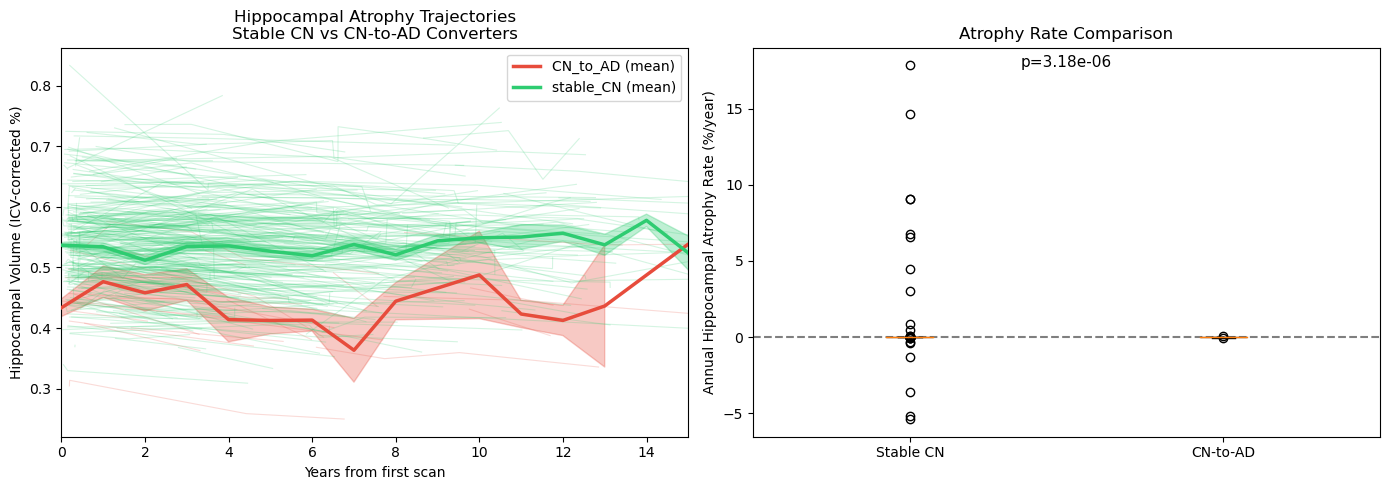

Mean atrophy rates (%/year):
Stable CN: 0.1651 ± 1.6139
CN-to-AD:  -0.0112 ± 0.0184
Mann-Whitney U: p=3.18e-06


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'stable_CN': '#2ecc71', 'CN_to_AD': '#e74c3c'}

ax = axes[0]
for trajectory, group in fs_analysis.groupby('trajectory'):
    for subject, subj_data in group.groupby('Subject'):
        subj_data = subj_data.sort_values('years')
        if len(subj_data) >= 2:
            ax.plot(subj_data['years'].to_numpy(), 
                   subj_data['hippo_ICV'].to_numpy(),
                   color=colors[trajectory], alpha=0.2, linewidth=0.8)

for trajectory, group in fs_analysis.groupby('trajectory'):
    group = group.copy()
    group['year_bin'] = group['years'].round(0)
    mean_traj = group.groupby('year_bin')['hippo_ICV'].agg(['mean', 'sem']).reset_index()
    ax.plot(mean_traj['year_bin'].to_numpy(), mean_traj['mean'].to_numpy(),
           color=colors[trajectory], linewidth=2.5,
           label=f"{trajectory} (mean)", zorder=5)
    ax.fill_between(mean_traj['year_bin'].to_numpy(),
                   (mean_traj['mean'] - mean_traj['sem']).to_numpy(),
                   (mean_traj['mean'] + mean_traj['sem']).to_numpy(),
                   color=colors[trajectory], alpha=0.3)

ax.set_xlabel('Years from first scan')
ax.set_ylabel('Hippocampal Volume (ICV-corrected %)')
ax.set_title('Hippocampal Atrophy Trajectories\nStable CN vs CN-to-AD Converters')
ax.legend()
ax.set_xlim(0, 15)

ax2 = axes[1]
rates = []
for subject, group in fs_analysis.groupby('Subject'):
    group = group.sort_values('years')
    if len(group) >= 2:
        slope, intercept, r, p, se = stats.linregress(
            group['years'].to_numpy(), group['hippo_ICV'].to_numpy())
        traj = group['trajectory'].iloc[0]
        rates.append({'OASISID': subject, 'atrophy_rate': slope, 'trajectory': traj})

rates_df = pd.DataFrame(rates)
cn_rates = rates_df[rates_df['trajectory']=='stable_CN']['atrophy_rate']
ad_rates = rates_df[rates_df['trajectory']=='CN_to_AD']['atrophy_rate']

ax2.boxplot([cn_rates.to_numpy(), ad_rates.to_numpy()], 
           labels=['Stable CN', 'CN-to-AD'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_ylabel('Annual Hippocampal Atrophy Rate (%/year)')
ax2.set_title('Atrophy Rate Comparison')

stat, p = stats.mannwhitneyu(cn_rates.to_numpy(), ad_rates.to_numpy(), 
                              alternative='two-sided')
ax2.text(0.5, 0.95, f'p={p:.2e}', transform=ax2.transAxes,
        ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../results/04_longitudinal_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean atrophy rates (%/year):")
print(f"Stable CN: {cn_rates.mean():.4f} ± {cn_rates.std():.4f}")
print(f"CN-to-AD:  {ad_rates.mean():.4f} ± {ad_rates.std():.4f}")
print(f"Mann-Whitney U: p={p:.2e}")

In [6]:
# Filter: minimum 1 year follow-up and at least 2 scans
rates_filtered = []
for subject, group in fs_analysis.groupby('Subject'):
    group = group.sort_values('years')
    if len(group) >= 2:
        followup = group['years'].max() - group['years'].min()
        if followup >= 1.0:  # at least 1 year between first and last scan
            slope, intercept, r, p, se = stats.linregress(
                group['years'].to_numpy(), group['hippo_ICV'].to_numpy())
            traj = group['trajectory'].iloc[0]
            rates_filtered.append({
                'OASISID': subject, 
                'atrophy_rate': slope, 
                'trajectory': traj,
                'followup_years': followup
            })

rates_df2 = pd.DataFrame(rates_filtered)
cn_r = rates_df2[rates_df2['trajectory']=='stable_CN']['atrophy_rate']
ad_r = rates_df2[rates_df2['trajectory']=='CN_to_AD']['atrophy_rate']

print(f"After filtering (>=1 year followup):")
print(f"Stable CN n={len(cn_r)}, CN-to-AD n={len(ad_r)}")
print(f"Stable CN: {cn_r.mean():.4f} ± {cn_r.std():.4f}")
print(f"CN-to-AD:  {ad_r.mean():.4f} ± {ad_r.std():.4f}")

stat, p = stats.mannwhitneyu(cn_r.to_numpy(), ad_r.to_numpy(), alternative='two-sided')
print(f"Mann-Whitney U: p={p:.2e}")

After filtering (>=1 year followup):
Stable CN n=311, CN-to-AD n=23
Stable CN: -0.0031 ± 0.0075
CN-to-AD:  -0.0136 ± 0.0116
Mann-Whitney U: p=4.05e-07


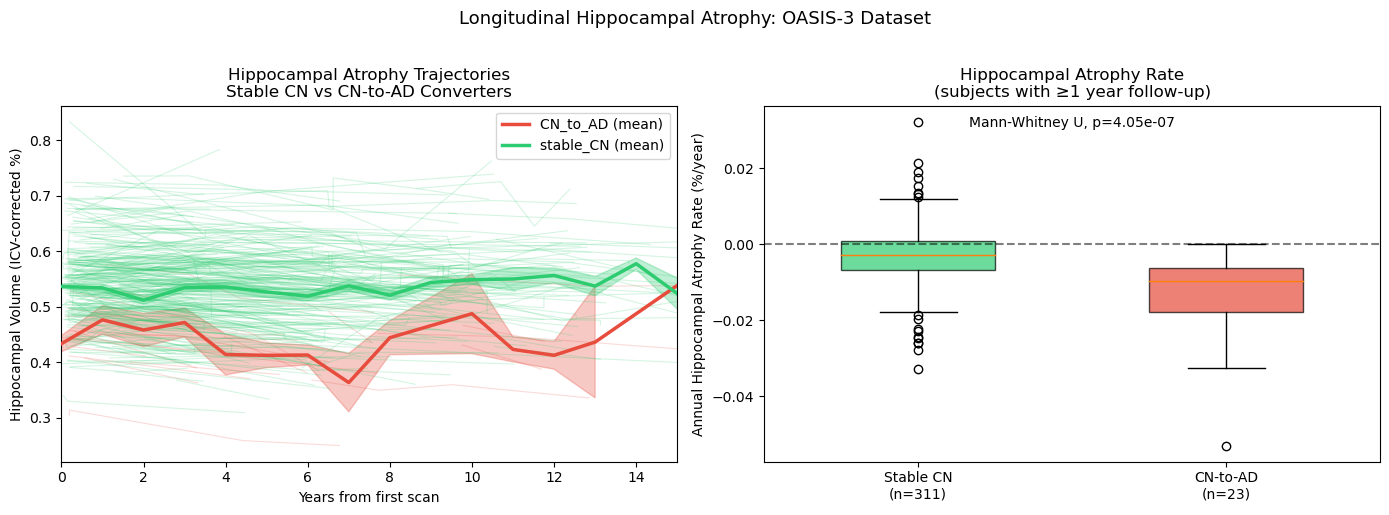

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: trajectories (same as before)
ax = axes[0]
for trajectory, group in fs_analysis.groupby('trajectory'):
    for subject, subj_data in group.groupby('Subject'):
        subj_data = subj_data.sort_values('years')
        if len(subj_data) >= 2:
            followup = subj_data['years'].max() - subj_data['years'].min()
            if followup >= 1.0:
                ax.plot(subj_data['years'].to_numpy(),
                       subj_data['hippo_ICV'].to_numpy(),
                       color=colors[trajectory], alpha=0.2, linewidth=0.8)

for trajectory, group in fs_analysis.groupby('trajectory'):
    group = group.copy()
    group['year_bin'] = group['years'].round(0)
    mean_traj = group.groupby('year_bin')['hippo_ICV'].agg(['mean','sem']).reset_index()
    ax.plot(mean_traj['year_bin'].to_numpy(), mean_traj['mean'].to_numpy(),
           color=colors[trajectory], linewidth=2.5, label=f"{trajectory} (mean)", zorder=5)
    ax.fill_between(mean_traj['year_bin'].to_numpy(),
                   (mean_traj['mean'] - mean_traj['sem']).to_numpy(),
                   (mean_traj['mean'] + mean_traj['sem']).to_numpy(),
                   color=colors[trajectory], alpha=0.3)

ax.set_xlabel('Years from first scan')
ax.set_ylabel('Hippocampal Volume (ICV-corrected %)')
ax.set_title('Hippocampal Atrophy Trajectories\nStable CN vs CN-to-AD Converters')
ax.legend()
ax.set_xlim(0, 15)

# Right: clean atrophy rate boxplot
ax2 = axes[1]
bp = ax2.boxplot([cn_r.to_numpy(), ad_r.to_numpy()],
                labels=['Stable CN\n(n=311)', 'CN-to-AD\n(n=23)'],
                patch_artist=True, widths=0.5)

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
for box in bp['boxes']:
    box.set_alpha(0.7)

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_ylabel('Annual Hippocampal Atrophy Rate (%/year)')
ax2.set_title('Hippocampal Atrophy Rate\n(subjects with ≥1 year follow-up)')
ax2.text(0.5, 0.97, f'Mann-Whitney U, p=4.05e-07',
        transform=ax2.transAxes, ha='center', fontsize=10,
        verticalalignment='top')

plt.suptitle('Longitudinal Hippocampal Atrophy: OASIS-3 Dataset', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/04_longitudinal_trajectories_clean.png', dpi=150, bbox_inches='tight')
plt.show()